# Bayesian Hyperparameter Tuning - Full 5-Phase Pipeline

**Strategy:**
- **Phases 1–4:** LinearSVC vs RandomForest, 3-fold stratified CV, with TF-IDF tuning and class_weight tuning
- **Phase 5:** HistGradientBoosting on ImpCHI + Stylometric features, **Leave-One-Out CV** on the ~240 Label 1+2 samples
- Each trial runs the **complete 5-phase pipeline end-to-end** on 3 folds, where Phase 5 uses LOOCV within each fold

### **Resume support:** if stopped early, re-running the notebook resumes from the last completed trial.

### **Checkpoint:** every 10 trials, `tuning/tuning_checkpoint.json` is overwritten with all results so far.

## 0. IMPORTS

In [1]:
import os, random, warnings, json, time
from datetime import timedelta
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd

import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

from sklearn.model_selection import StratifiedKFold, LeaveOneOut
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import chi2
from sklearn.svm import LinearSVC
from sklearn.ensemble import (RandomForestClassifier,
                              HistGradientBoostingClassifier)
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, csr_matrix

import optuna
from optuna.samplers import TPESampler

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 359956
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)



c:\Users\simop\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. DATA & PREPROCESSING

In [2]:
for res in ["punkt", "punkt_tab", "wordnet", "stopwords",
            "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng"]:
    nltk.download(res, quiet=True)

df = pd.read_csv("train.csv").dropna(subset=["TEXT", "LABEL"]).reset_index(drop=True)
print(f"Loaded {len(df)} rows")
print(df["LABEL"].value_counts().sort_index())

lemmatizer = WordNetLemmatizer()

def clean_text_none(text):
    text = str(text).lower()
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t.isalpha()]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

df["text_clean"] = df["TEXT"].apply(clean_text_none)
print("text cleaned")

# ── Stylometric features ──────────────────────────────────────
def extract_stylometric(text):
    text = str(text)
    sentences = sent_tokenize(text)
    n_sentences = max(len(sentences), 1)
    sent_lengths = [len(word_tokenize(s)) for s in sentences]
    words = word_tokenize(text)
    alpha_words = [w for w in words if w.isalpha()]
    n_words = max(len(alpha_words), 1)
    word_lengths = [len(w) for w in alpha_words] if alpha_words else [0]
    n_chars = max(len(text), 1)

    n_commas = text.count(",")
    n_periods = text.count(".")
    n_exclaim = text.count("!")
    n_question = text.count("?")
    n_semicolon = text.count(";")
    n_colon = text.count(":")
    n_dash = text.count("\u2014") + text.count("-")
    n_parens = text.count("(") + text.count(")")
    n_quotes = text.count('"') + text.count("'") + text.count("\u201c") + text.count("\u201d")

    try:
        tags = pos_tag(alpha_words[:200])
        tag_counts = Counter(t for _, t in tags)
        n_tagged = max(sum(tag_counts.values()), 1)
        pct_noun = (tag_counts.get("NN", 0) + tag_counts.get("NNS", 0) +
                    tag_counts.get("NNP", 0) + tag_counts.get("NNPS", 0)) / n_tagged
        pct_verb = (tag_counts.get("VB", 0) + tag_counts.get("VBD", 0) +
                    tag_counts.get("VBG", 0) + tag_counts.get("VBN", 0) +
                    tag_counts.get("VBP", 0) + tag_counts.get("VBZ", 0)) / n_tagged
        pct_adj = (tag_counts.get("JJ", 0) + tag_counts.get("JJR", 0) +
                   tag_counts.get("JJS", 0)) / n_tagged
        pct_adv = (tag_counts.get("RB", 0) + tag_counts.get("RBR", 0) +
                   tag_counts.get("RBS", 0)) / n_tagged
    except:
        pct_noun = pct_verb = pct_adj = pct_adv = 0.0

    unique_words = set(w.lower() for w in alpha_words)
    ttr = len(unique_words) / n_words
    pct_short = sum(1 for w in alpha_words if len(w) <= 3) / n_words
    pct_long = sum(1 for w in alpha_words if len(w) >= 8) / n_words

    return {
        "n_chars": n_chars, "n_words": n_words, "n_sentences": n_sentences,
        "avg_word_len": np.mean(word_lengths), "std_word_len": np.std(word_lengths),
        "avg_sent_len": np.mean(sent_lengths),
        "std_sent_len": np.std(sent_lengths) if len(sent_lengths) > 1 else 0,
        "max_sent_len": max(sent_lengths), "min_sent_len": min(sent_lengths),
        "comma_rate": n_commas / n_words, "period_rate": n_periods / n_words,
        "exclaim_rate": n_exclaim / n_words, "question_rate": n_question / n_words,
        "semicolon_rate": n_semicolon / n_words, "colon_rate": n_colon / n_words,
        "dash_rate": n_dash / n_words, "paren_rate": n_parens / n_words,
        "quote_rate": n_quotes / n_words,
        "total_punct_rate": (n_commas + n_periods + n_exclaim + n_question +
                             n_semicolon + n_colon) / n_words,
        "pct_noun": pct_noun, "pct_verb": pct_verb,
        "pct_adj": pct_adj, "pct_adv": pct_adv,
        "noun_verb_ratio": pct_noun / max(pct_verb, 0.001),
        "ttr": ttr, "pct_short_words": pct_short, "pct_long_words": pct_long,
        "words_per_sentence": n_words / n_sentences,
        "chars_per_word": n_chars / n_words,
    }

print("\nExtracting stylometric features")
stylo_df = pd.DataFrame(df["TEXT"].apply(extract_stylometric).tolist())
STYLO_ALL = stylo_df.values.astype(float)
print(f"Stylometric features: {STYLO_ALL.shape}")
print("Preprocessing done.\n")



Loaded 2400 rows
LABEL
0    1520
1      80
2     160
3      80
4     240
5     320
Name: count, dtype: int64
text cleaned

Extracting stylometric features
Stylometric features: (2400, 29)
Preprocessing done.



## 2. GLOBALS & FOLD INDICES

In [3]:
TEXTS = df["text_clean"].values
RAW_TEXTS = df["TEXT"].values
LABELS = df["LABEL"].values

# 3-fold for end-to-end pipeline
N_FOLDS = 3
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
FOLD_INDICES = list(skf.split(TEXTS, LABELS))

# Pre-compute label 1+2 indices for LOOCV
MASK_12_GLOBAL = np.isin(LABELS, [1, 2])
IDX_12_GLOBAL = np.where(MASK_12_GLOBAL)[0]
print(f"Label 1+2 samples: {len(IDX_12_GLOBAL)} (for LOOCV)")

N_TRIALS = 340

# Checkpoint paths
TUNING_DIR = Path("tuning")
TUNING_DIR.mkdir(exist_ok=True)
CHECKPOINT_FILE = TUNING_DIR / "tuning_checkpoint.json"
RESULTS_FILE = TUNING_DIR / "tuning_results.json"
TOP5_FILE = TUNING_DIR / "tuning_top5.json"



Label 1+2 samples: 240 (for LOOCV)


## 3. FEATURE BUILDERS

In [4]:
def build_impchi(X_tr_text, X_other_text, y_tr, k_per_class,
                 impchi_max_feat=15000, impchi_ngram=(1, 2), impchi_min_df=2):
    """ImpCHI: top-K features per class via Chi-squared."""
    tfidf = TfidfVectorizer(max_features=impchi_max_feat, ngram_range=impchi_ngram,
                            sublinear_tf=True, min_df=impchi_min_df,
                            strip_accents="unicode", analyzer="word")
    X_tr_full = tfidf.fit_transform(X_tr_text)
    X_other_full = tfidf.transform(X_other_text)

    classes = np.unique(y_tr)
    selected_indices = set()
    for cls in classes:
        y_binary = (y_tr == cls).astype(int)
        scores, _ = chi2(X_tr_full, y_binary)
        top_k_idx = np.argsort(scores)[-k_per_class:]
        selected_indices.update(top_k_idx)

    selected = sorted(selected_indices)
    return X_tr_full[:, selected], X_other_full[:, selected]


def build_stylo(tr_idx, val_idx):
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(STYLO_ALL[tr_idx])
    X_val = scaler.transform(STYLO_ALL[val_idx])
    return csr_matrix(X_tr), csr_matrix(X_val), scaler


def run_loocv_phase5(global_idx_12, y_12, hgb_params, impchi_params):
    """
    Leave-One-Out CV on label 1+2 subset.
    Returns macro F1 over all 240 LOO predictions.
    """
    texts_12 = TEXTS[global_idx_12]
    n = len(global_idx_12)
    loo_preds = np.zeros(n, dtype=int)

    for i in range(n):
        tr_mask = np.ones(n, dtype=bool)
        tr_mask[i] = False

        tr_idx_local = np.where(tr_mask)[0]
        val_idx_local = i

        tr_global = global_idx_12[tr_idx_local]
        val_global = global_idx_12[[val_idx_local]]

        y_tr_loo = y_12[tr_idx_local]

        # ImpCHI
        X_tr_chi, X_val_chi = build_impchi(
            texts_12[tr_idx_local], texts_12[[val_idx_local]],
            y_tr_loo,
            k_per_class=impchi_params["k_per_class"],
            impchi_max_feat=impchi_params["max_features"],
            impchi_ngram=impchi_params["ngram_range"],
            impchi_min_df=impchi_params["min_df"]
        )

        # Stylo
        X_tr_sty, X_val_sty, _ = build_stylo(tr_global, val_global)

        # Concat -> dense
        X_tr_p5 = hstack([X_tr_chi, X_tr_sty]).toarray()
        X_val_p5 = hstack([X_val_chi, X_val_sty]).toarray()

        m5 = HistGradientBoostingClassifier(
            max_iter=hgb_params["max_iter"],
            max_depth=hgb_params["max_depth"],
            learning_rate=hgb_params["learning_rate"],
            max_leaf_nodes=hgb_params["max_leaf_nodes"],
            min_samples_leaf=hgb_params["min_samples_leaf"],
            l2_regularization=hgb_params["l2_regularization"],
            class_weight=hgb_params["class_weight"],
            random_state=SEED
        )
        m5.fit(X_tr_p5, y_tr_loo)
        loo_preds[i] = m5.predict(X_val_p5)[0]

    return f1_score(y_12, loo_preds, average="macro")



## 4. OPTUNA OBJECTIVE

In [5]:
def objective(trial):
    # ══════════════════════════════════════════════════════════
    # A. PHASES 1–4: model choice + hyperparameters
    # ══════════════════════════════════════════════════════════
    p14_model = trial.suggest_categorical("p14_model", ["linearsvc", "random_forest"])
    p14_class_weight = trial.suggest_categorical("p14_class_weight", ["balanced", "none"])
    cw = "balanced" if p14_class_weight == "balanced" else None

    # TF-IDF
    tfidf_max_features = trial.suggest_int("tfidf_max_features", 3000, 50000, log=True)
    tfidf_ngram_max = trial.suggest_int("tfidf_ngram_max", 1, 3)
    tfidf_sublinear = trial.suggest_categorical("tfidf_sublinear", [True, False])
    tfidf_min_df = trial.suggest_int("tfidf_min_df", 1, 5)

    if p14_model == "linearsvc":
        svc_C = trial.suggest_float("svc_C", 0.05, 20.0, log=True)
    else:
        rf_n = trial.suggest_int("rf_n_estimators", 100, 500)
        rf_depth = trial.suggest_int("rf_max_depth", 5, 30)
        rf_min_split = trial.suggest_int("rf_min_samples_split", 2, 8)
        rf_min_leaf = trial.suggest_int("rf_min_samples_leaf", 1, 5)

    # ══════════════════════════════════════════════════════════
    # B. PHASE 5: HistGB + ImpCHI params
    # ══════════════════════════════════════════════════════════
    hgb_max_iter = trial.suggest_int("hgb_max_iter", 30, 200)
    hgb_max_depth = trial.suggest_int("hgb_max_depth", 3, 16)
    hgb_lr = trial.suggest_float("hgb_learning_rate", 0.01, 0.3, log=True)
    hgb_leaves = trial.suggest_int("hgb_max_leaf_nodes", 5, 31)
    hgb_min_leaf = trial.suggest_int("hgb_min_samples_leaf", 3, 20)
    hgb_l2 = trial.suggest_float("hgb_l2_regularization", 0.0, 10.0)
    hgb_cw = trial.suggest_categorical("hgb_class_weight", ["balanced", "none"])

    impchi_k = trial.suggest_int("impchi_k_per_class", 15, 80)
    impchi_max_feat = trial.suggest_int("impchi_max_features", 5000, 20000, log=True)
    impchi_ngram_max = trial.suggest_int("impchi_ngram_max", 1, 3)
    impchi_min_df = trial.suggest_int("impchi_min_df", 1, 5)

    hgb_params = {
        "max_iter": hgb_max_iter, "max_depth": hgb_max_depth,
        "learning_rate": hgb_lr, "max_leaf_nodes": hgb_leaves,
        "min_samples_leaf": hgb_min_leaf, "l2_regularization": hgb_l2,
        "class_weight": "balanced" if hgb_cw == "balanced" else None,
    }
    impchi_params = {
        "k_per_class": impchi_k, "max_features": impchi_max_feat,
        "ngram_range": (1, impchi_ngram_max), "min_df": impchi_min_df,
    }

    # ══════════════════════════════════════════════════════════
    # C. 3-FOLD CV - full 5-phase pipeline
    # ══════════════════════════════════════════════════════════
    fold_scores = []

    for train_idx, val_idx in FOLD_INDICES:
        X_tr_text = TEXTS[train_idx]
        X_val_text = TEXTS[val_idx]
        y_tr = LABELS[train_idx]
        y_val = LABELS[val_idx]

        # ── TF-IDF ────────────────────────────────────────────
        tfidf = TfidfVectorizer(
            max_features=tfidf_max_features,
            ngram_range=(1, tfidf_ngram_max),
            sublinear_tf=tfidf_sublinear,
            min_df=tfidf_min_df,
            strip_accents="unicode", analyzer="word"
        )
        X_tr_tfidf = tfidf.fit_transform(X_tr_text)
        X_val_tfidf = tfidf.transform(X_val_text)

        # ── Model builder ─────────────────────────────────────
        def make_model():
            if p14_model == "linearsvc":
                return LinearSVC(C=svc_C, max_iter=3000,
                                 class_weight=cw, random_state=SEED)
            else:
                return RandomForestClassifier(
                    n_estimators=rf_n, max_depth=rf_depth,
                    min_samples_split=rf_min_split,
                    min_samples_leaf=rf_min_leaf,
                    class_weight=cw, random_state=SEED, n_jobs=-1)

        final_pred = np.full(len(y_val), -1, dtype=int)
        val_pos = np.arange(len(y_val))

        # ── Phase 1: Human vs AI ──────────────────────────────
        m1 = make_model()
        m1.fit(X_tr_tfidf, (y_tr != 0).astype(int))
        pred_p1 = m1.predict(X_val_tfidf)
        final_pred[pred_p1 == 0] = 0
        ai_pos = val_pos[pred_p1 == 1]

        # ── Phase 2: Label 4 vs (1,2,3,5) ────────────────────
        ai_mask_tr = y_tr != 0
        m2 = make_model()
        m2.fit(X_tr_tfidf[ai_mask_tr], (y_tr[ai_mask_tr] == 4).astype(int))
        if len(ai_pos) > 0:
            pred_p2 = m2.predict(X_val_tfidf[ai_pos])
            final_pred[ai_pos[pred_p2 == 1]] = 4
            remaining = ai_pos[pred_p2 == 0]
        else:
            remaining = np.array([], dtype=int)

        # ── Phase 3: Label 3 vs (1,2,5) ──────────────────────
        mask_1235 = np.isin(y_tr, [1, 2, 3, 5])
        m3 = make_model()
        m3.fit(X_tr_tfidf[mask_1235], (y_tr[mask_1235] == 3).astype(int))
        if len(remaining) > 0:
            pred_p3 = m3.predict(X_val_tfidf[remaining])
            final_pred[remaining[pred_p3 == 1]] = 3
            remaining = remaining[pred_p3 == 0]

        # ── Phase 4: Label 5 vs (1,2) ────────────────────────
        mask_125 = np.isin(y_tr, [1, 2, 5])
        m4 = make_model()
        m4.fit(X_tr_tfidf[mask_125], (y_tr[mask_125] == 5).astype(int))
        if len(remaining) > 0:
            pred_p4 = m4.predict(X_val_tfidf[remaining])
            final_pred[remaining[pred_p4 == 1]] = 5
            remaining = remaining[pred_p4 == 0]

        # ── Phase 5: LOOCV on label 1+2 within this fold ─────
        # Get global indices of label 1+2 in training set
        tr_global_12 = train_idx[np.isin(y_tr, [1, 2])]
        y_tr_12 = LABELS[tr_global_12]

        # Run LOOCV on the training label 1+2 subset
        f1_p5_loo = run_loocv_phase5(
            tr_global_12, y_tr_12, hgb_params, impchi_params
        )

        # For end-to-end F1: train Phase 5 on full training 1+2,
        # predict on val samples reaching phase 5
        if len(remaining) > 0:
            val_global_p5 = val_idx[remaining]
            y_val_p5 = y_val[remaining]

            X_tr_chi, X_val_chi = build_impchi(
                TEXTS[tr_global_12], TEXTS[val_global_p5],
                y_tr_12,
                k_per_class=impchi_params["k_per_class"],
                impchi_max_feat=impchi_params["max_features"],
                impchi_ngram=impchi_params["ngram_range"],
                impchi_min_df=impchi_params["min_df"]
            )
            X_tr_sty, X_val_sty, _ = build_stylo(tr_global_12, val_global_p5)

            X_tr_p5 = hstack([X_tr_chi, X_tr_sty]).toarray()
            X_val_p5 = hstack([X_val_chi, X_val_sty]).toarray()

            m5 = HistGradientBoostingClassifier(
                **hgb_params, random_state=SEED
            )
            m5.fit(X_tr_p5, y_tr_12)
            pred_p5 = m5.predict(X_val_p5)
            final_pred[remaining] = pred_p5

        # Fallback
        if (final_pred == -1).any():
            final_pred[final_pred == -1] = 1

        fold_scores.append(f1_score(y_val, final_pred, average="macro"))

    # Store LOOCV F1 as user attribute for analysis
    trial.set_user_attr("f1_p5_loocv", f1_p5_loo)

    return float(np.mean(fold_scores))



## 5. CHECKPOINT / RESUME LOGIC

In [6]:
def save_checkpoint(study):
    #Save all completed trials to checkpoint JSON
    records = []
    for t in study.trials:
        if t.state == optuna.trial.TrialState.COMPLETE:
            records.append({
                "number": t.number,
                "f1_mean": t.value,
                "f1_p5_loocv": t.user_attrs.get("f1_p5_loocv"),
                "params": t.params,
                "duration_s": round(t.duration.total_seconds(), 1) if t.duration else None,
            })
    records.sort(key=lambda x: x["f1_mean"], reverse=True)
    with open(CHECKPOINT_FILE, "w") as fp:
        json.dump(records, fp, indent=2, default=str)
    return len(records)


def load_completed_count():
    #Count how many trials were already completed (for resume)
    if CHECKPOINT_FILE.exists():
        with open(CHECKPOINT_FILE, "r") as fp:
            data = json.load(fp)
        return len(data)
    return 0


## 6. RUN OPTUNA

In [7]:
already_done = load_completed_count()
remaining_trials = max(0, N_TRIALS - already_done)

print(f"Target: {N_TRIALS} trials")
print(f"Already completed: {already_done}")
print(f"Remaining: {remaining_trials}")

if remaining_trials == 0:
    print("All trials already completed! Skipping to results.")
else:
    # Create or load study (SQLite for persistence)
    storage_path = f"sqlite:///{TUNING_DIR}/optuna_study.db"
    study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=SEED),
        study_name="5phase_final",
        storage=storage_path,
        load_if_exists=True,
    )

    t0 = time.time()
    best_so_far = [0.0]

    # Initialize best from existing trials
    if len(study.trials) > 0:
        completed = [t for t in study.trials
                     if t.state == optuna.trial.TrialState.COMPLETE]
        if completed:
            best_so_far[0] = max(t.value for t in completed)

    def trial_callback(study, trial):
        elapsed = time.time() - t0
        n_done = trial.number + 1 - already_done
        if n_done <= 0:
            return
        avg = elapsed / n_done
        rem = avg * (remaining_trials - n_done)

        if trial.value and trial.value > best_so_far[0]:
            best_so_far[0] = trial.value

        if n_done % 10 == 0 or n_done == 1:
            print(
                f"  Trial {trial.number+1:>4d} (new #{n_done}/{remaining_trials})  "
                f"F1={trial.value:.4f}  "
                f"best={best_so_far[0]:.4f}  "
                f"| {timedelta(seconds=int(elapsed))} elapsed  "
                f"~{timedelta(seconds=int(rem))} remaining"
            )

        # Checkpoint every 10 new trials
        if n_done % 10 == 0:
            n_saved = save_checkpoint(study)
            print(f"    CHECKPOINT {n_saved} trials -> {CHECKPOINT_FILE}")

    print(f"\nStarting Optuna ({remaining_trials} trials)\n")
    study.optimize(objective, n_trials=remaining_trials, callbacks=[trial_callback])

    total_time = time.time() - t0
    print(f"\nFinished! {remaining_trials} new trials in {timedelta(seconds=int(total_time))}")
    print(f"Best F1-macro: {study.best_value:.4f}")

    # Final save
    save_checkpoint(study)

Target: 340 trials
Already completed: 338
Remaining: 2

Starting Optuna (2 trials)


Finished! 2 new trials in 0:03:08
Best F1-macro: 0.9484


## 7. SAVE RESULTS & LOAD CHECKPOINT


In [8]:
# Also copy checkpoint to results
if CHECKPOINT_FILE.exists():
    with open(CHECKPOINT_FILE, "r") as fp:
        all_results = json.load(fp)
    with open(RESULTS_FILE, "w") as fp:
        json.dump(all_results, fp, indent=2, default=str)
    print(f"Saved {len(all_results)} trials -> {RESULTS_FILE}")
else:
    print("No checkpoint file found. Run the tuning first.")
    all_results = []



Saved 340 trials -> tuning\tuning_results.json


## 8. TOP 10 FROM OPTUNA -> 3-FOLD + LOOCV VALIDATION
For each of the top 10 configs from Optuna:
1. **LOOCV on Phase 5** (once): train on 239, predict 1, repeat 240 times → pre-computed predictions
2. **3-fold CV end-to-end**: Phases 1–4 run normally per fold. For Phase 5, use the pre-computed LOOCV predictions.

This gives a proper end-to-end F1 while running LOOCV only once per config.


In [9]:
if not all_results and CHECKPOINT_FILE.exists():
    with open(CHECKPOINT_FILE, "r") as fp:
        all_results = json.load(fp)

top10_optuna = all_results[:10]

print(f"Loaded {len(all_results)} trials. Validating top 10.\n")
print("=" * 90)
print("  TOP 10 FROM OPTUNA (by Optuna score)")
print("=" * 90)
for rank, r in enumerate(top10_optuna, 1):
    print(f"  #{rank}  Trial {r['number']}  Optuna_F1={r['f1_mean']:.4f}")

# ── Pre-compute globals for label 1+2 ────────────────────────
TEXTS_12 = TEXTS[IDX_12_GLOBAL]
LABELS_12 = LABELS[IDX_12_GLOBAL]

# ── Validation loop ───────────────────────────────────────────
print("\n" + "=" * 90)
print("  RUNNING 3-FOLD + LOOCV VALIDATION")
print("=" * 90)

validated_results = []

for cfg_rank, r in enumerate(top10_optuna, 1):
    p = r["params"]
    t_start = time.time()

    print(f"\n  Config #{cfg_rank} (Trial {r['number']}, Optuna F1={r['f1_mean']:.4f})")

    # ── Extract params ────────────────────────────────────────
    p14_model = p["p14_model"]
    cw_14 = "balanced" if p["p14_class_weight"] == "balanced" else None

    hgb_params = {
        "max_iter": p["hgb_max_iter"],
        "max_depth": p["hgb_max_depth"],
        "learning_rate": p["hgb_learning_rate"],
        "max_leaf_nodes": p["hgb_max_leaf_nodes"],
        "min_samples_leaf": p["hgb_min_samples_leaf"],
        "l2_regularization": p["hgb_l2_regularization"],
        "class_weight": "balanced" if p["hgb_class_weight"] == "balanced" else None,
    }
    impchi_params = {
        "k_per_class": p["impchi_k_per_class"],
        "max_features": p["impchi_max_features"],
        "ngram_range": (1, p["impchi_ngram_max"]),
        "min_df": p["impchi_min_df"],
    }

    def make_model_14():
        if p14_model == "linearsvc":
            return LinearSVC(C=p["svc_C"], max_iter=3000,
                             class_weight=cw_14, random_state=SEED)
        else:
            return RandomForestClassifier(
                n_estimators=p["rf_n_estimators"], max_depth=p["rf_max_depth"],
                min_samples_split=p["rf_min_samples_split"],
                min_samples_leaf=p["rf_min_samples_leaf"],
                class_weight=cw_14, random_state=SEED, n_jobs=-1)

    # ══════════════════════════════════════════════════════════
    # STEP 1: LOOCV on Phase 5 (runs once, 240 iterations)
    # ══════════════════════════════════════════════════════════
    print(f"    LOOCV Phase 5 ({len(LABELS_12)} samples) …", end=" ", flush=True)

    n_12 = len(LABELS_12)
    loo_preds_all = np.zeros(n_12, dtype=int)

    for i in range(n_12):
        tr_mask = np.ones(n_12, dtype=bool)
        tr_mask[i] = False
        tr_idx_local = np.where(tr_mask)[0]

        tr_global = IDX_12_GLOBAL[tr_idx_local]
        val_global = IDX_12_GLOBAL[[i]]
        y_tr_loo = LABELS_12[tr_idx_local]

        # ImpCHI
        X_tr_chi, X_val_chi = build_impchi(
            TEXTS_12[tr_idx_local], TEXTS_12[[i]],
            y_tr_loo,
            k_per_class=impchi_params["k_per_class"],
            impchi_max_feat=impchi_params["max_features"],
            impchi_ngram=impchi_params["ngram_range"],
            impchi_min_df=impchi_params["min_df"])

        # Stylo
        X_tr_sty, X_val_sty, _ = build_stylo(tr_global, val_global)

        X_tr_p5 = hstack([X_tr_chi, X_tr_sty]).toarray()
        X_val_p5 = hstack([X_val_chi, X_val_sty]).toarray()

        m5 = HistGradientBoostingClassifier(**hgb_params, random_state=SEED)
        m5.fit(X_tr_p5, y_tr_loo)
        loo_preds_all[i] = m5.predict(X_val_p5)[0]

    f1_p5_loo = f1_score(LABELS_12, loo_preds_all, average="macro")
    print(f"F1_LOOCV={f1_p5_loo:.4f}")

    # Build a lookup: global_index → LOOCV prediction
    loo_lookup = {int(IDX_12_GLOBAL[i]): int(loo_preds_all[i]) for i in range(n_12)}

    # ══════════════════════════════════════════════════════════
    # STEP 2: 3-fold end-to-end (phases 1-4 normal, phase 5 from LOOCV)
    # ══════════════════════════════════════════════════════════
    fold_scores = []
    fold_f1_p14 = []

    for fold_idx, (train_idx, val_idx) in enumerate(FOLD_INDICES):
        X_tr_text = TEXTS[train_idx]
        X_val_text = TEXTS[val_idx]
        y_tr = LABELS[train_idx]
        y_val = LABELS[val_idx]

        # TF-IDF
        tfidf = TfidfVectorizer(
            max_features=p["tfidf_max_features"],
            ngram_range=(1, p["tfidf_ngram_max"]),
            sublinear_tf=p["tfidf_sublinear"],
            min_df=p["tfidf_min_df"],
            strip_accents="unicode", analyzer="word")
        X_tr_tfidf = tfidf.fit_transform(X_tr_text)
        X_val_tfidf = tfidf.transform(X_val_text)

        final_pred = np.full(len(y_val), -1, dtype=int)
        val_pos = np.arange(len(y_val))

        # Phase 1: Human vs AI
        m1 = make_model_14()
        m1.fit(X_tr_tfidf, (y_tr != 0).astype(int))
        pred_p1 = m1.predict(X_val_tfidf)
        final_pred[pred_p1 == 0] = 0
        ai_pos = val_pos[pred_p1 == 1]

        # Phase 2: Label 4 vs (1,2,3,5)
        ai_mask_tr = y_tr != 0
        m2 = make_model_14()
        m2.fit(X_tr_tfidf[ai_mask_tr], (y_tr[ai_mask_tr] == 4).astype(int))
        if len(ai_pos) > 0:
            pred_p2 = m2.predict(X_val_tfidf[ai_pos])
            final_pred[ai_pos[pred_p2 == 1]] = 4
            remaining = ai_pos[pred_p2 == 0]
        else:
            remaining = np.array([], dtype=int)

        # Phase 3: Label 3 vs (1,2,5)
        mask_1235 = np.isin(y_tr, [1, 2, 3, 5])
        m3 = make_model_14()
        m3.fit(X_tr_tfidf[mask_1235], (y_tr[mask_1235] == 3).astype(int))
        if len(remaining) > 0:
            pred_p3 = m3.predict(X_val_tfidf[remaining])
            final_pred[remaining[pred_p3 == 1]] = 3
            remaining = remaining[pred_p3 == 0]

        # Phase 4: Label 5 vs (1,2)
        mask_125 = np.isin(y_tr, [1, 2, 5])
        m4 = make_model_14()
        m4.fit(X_tr_tfidf[mask_125], (y_tr[mask_125] == 5).astype(int))
        if len(remaining) > 0:
            pred_p4 = m4.predict(X_val_tfidf[remaining])
            final_pred[remaining[pred_p4 == 1]] = 5
            remaining = remaining[pred_p4 == 0]

        # Phase 5: use pre-computed LOOCV predictions
        if len(remaining) > 0:
            for pos in remaining:
                global_idx = val_idx[pos]
                if global_idx in loo_lookup:
                    final_pred[pos] = loo_lookup[global_idx]
                else:
                    final_pred[pos] = 1  # fallback

        # Fallback
        if (final_pred == -1).any():
            final_pred[final_pred == -1] = 1

        fold_scores.append(f1_score(y_val, final_pred, average="macro"))

    f1_e2e = float(np.mean(fold_scores))
    elapsed = time.time() - t_start

    validated_results.append({
        "optuna_rank": cfg_rank,
        "trial": r["number"],
        "f1_optuna": r["f1_mean"],
        "f1_p5_loocv": f1_p5_loo,
        "f1_e2e_3fold": f1_e2e,
        "f1_folds": [float(s) for s in fold_scores],
        "params": p,
        "validation_time_s": round(elapsed, 1),
    })

    print(f"    3-fold E2E: {f1_e2e:.4f}  (folds: {[f'{s:.4f}' for s in fold_scores]})  "
          f"({elapsed:.0f}s total)")



Loaded 340 trials. Validating top 10.

  TOP 10 FROM OPTUNA (by Optuna score)
  #1  Trial 168  Optuna_F1=0.9484
  #2  Trial 301  Optuna_F1=0.9483
  #3  Trial 225  Optuna_F1=0.9482
  #4  Trial 327  Optuna_F1=0.9473
  #5  Trial 227  Optuna_F1=0.9472
  #6  Trial 263  Optuna_F1=0.9469
  #7  Trial 264  Optuna_F1=0.9469
  #8  Trial 286  Optuna_F1=0.9467
  #9  Trial 75  Optuna_F1=0.9467
  #10  Trial 300  Optuna_F1=0.9467

  RUNNING 3-FOLD + LOOCV VALIDATION

  Config #1 (Trial 168, Optuna F1=0.9484)
    LOOCV Phase 5 (240 samples) … F1_LOOCV=0.8560
    3-fold E2E: 0.9481  (folds: ['0.9441', '0.9538', '0.9463'])  (72s total)

  Config #2 (Trial 301, Optuna F1=0.9483)
    LOOCV Phase 5 (240 samples) … F1_LOOCV=0.8425
    3-fold E2E: 0.9435  (folds: ['0.9534', '0.9347', '0.9423'])  (78s total)

  Config #3 (Trial 225, Optuna F1=0.9482)
    LOOCV Phase 5 (240 samples) … F1_LOOCV=0.8626
    3-fold E2E: 0.9502  (folds: ['0.9584', '0.9452', '0.9471'])  (69s total)

  Config #4 (Trial 327, Optuna F1=

## 9. FINAL TOP 5 (ranked by end-to-end 3-fold F1)


In [10]:
validated_results.sort(key=lambda x: x["f1_e2e_3fold"], reverse=True)

print("\n" + "=" * 90)
print("  FINAL TOP 5 (ranked by end-to-end 3-fold macro F1)")
print("=" * 90)

print(f"\n{'Rank':<5} {'Trial':<8} {'Optuna#':<9} {'F1_Optuna':>10} {'F1_LOOCV':>10} {'F1_E2E':>10}")
print("-" * 55)

top5_final = []
for rank, r in enumerate(validated_results[:5], 1):
    p = r["params"]
    print(f"{rank:<5} {r['trial']:<8} #{r['optuna_rank']:<8} "
          f"{r['f1_optuna']:>10.4f} {r['f1_p5_loocv']:>10.4f} {r['f1_e2e_3fold']:>10.4f}")

    top5_final.append({
        "rank": rank,
        "trial": r["trial"],
        "f1_e2e_3fold": r["f1_e2e_3fold"],
        "f1_p5_loocv": r["f1_p5_loocv"],
        "f1_optuna": r["f1_optuna"],
        "f1_folds": r["f1_folds"],
        "params": p,
    })

# Print details for top 5
for rank, r in enumerate(validated_results[:5], 1):
    p = r["params"]
    print(f"\n  ── #{rank}  Trial {r['trial']}  F1_E2E = {r['f1_e2e_3fold']:.4f} ──")
    print(f"  [Phases 1-4] {p['p14_model']}  class_weight={p['p14_class_weight']}")
    print(f"    TF-IDF: max_features={p['tfidf_max_features']}, "
          f"ngram=(1,{p['tfidf_ngram_max']}), "
          f"sublinear={p['tfidf_sublinear']}, min_df={p['tfidf_min_df']}")
    if p["p14_model"] == "linearsvc":
        print(f"    C={p.get('svc_C', 'N/A'):.4f}")
    else:
        print(f"    n_estimators={p.get('rf_n_estimators')}, "
              f"max_depth={p.get('rf_max_depth')}, "
              f"min_split={p.get('rf_min_samples_split')}, "
              f"min_leaf={p.get('rf_min_samples_leaf')}")

    print(f"  [Phase 5] HistGB + ImpCHI+Stylo  class_weight={p.get('hgb_class_weight')}")
    for k in ["hgb_max_iter", "hgb_max_depth", "hgb_learning_rate",
              "hgb_max_leaf_nodes", "hgb_min_samples_leaf", "hgb_l2_regularization",
              "impchi_k_per_class", "impchi_max_features", "impchi_ngram_max", "impchi_min_df"]:
        v = p.get(k)
        if v is not None:
            v_str = f"{v:.4f}" if isinstance(v, float) else str(v)
            print(f"    {k:<30s}: {v_str}")
    print(f"  Fold scores: {r['f1_folds']}")
    print(f"  Phase 5 LOOCV F1: {r['f1_p5_loocv']:.4f}")

with open(TOP5_FILE, "w") as fp:
    json.dump(top5_final, fp, indent=2, default=str)
print(f"\nSaved: {TOP5_FILE}")




  FINAL TOP 5 (ranked by end-to-end 3-fold macro F1)

Rank  Trial    Optuna#    F1_Optuna   F1_LOOCV     F1_E2E
-------------------------------------------------------
1     286      #8            0.9467     0.8711     0.9519
2     225      #3            0.9482     0.8626     0.9502
3     264      #7            0.9469     0.8626     0.9502
4     168      #1            0.9484     0.8560     0.9481
5     263      #6            0.9469     0.8527     0.9469

  ── #1  Trial 286  F1_E2E = 0.9519 ──
  [Phases 1-4] linearsvc  class_weight=balanced
    TF-IDF: max_features=4560, ngram=(1,1), sublinear=True, min_df=1
    C=3.8934
  [Phase 5] HistGB + ImpCHI+Stylo  class_weight=balanced
    hgb_max_iter                  : 120
    hgb_max_depth                 : 8
    hgb_learning_rate             : 0.0498
    hgb_max_leaf_nodes            : 8
    hgb_min_samples_leaf          : 5
    hgb_l2_regularization         : 8.0871
    impchi_k_per_class            : 63
    impchi_max_features           :

## 10. PLOTS
From checkpoint — works even if stopped early.


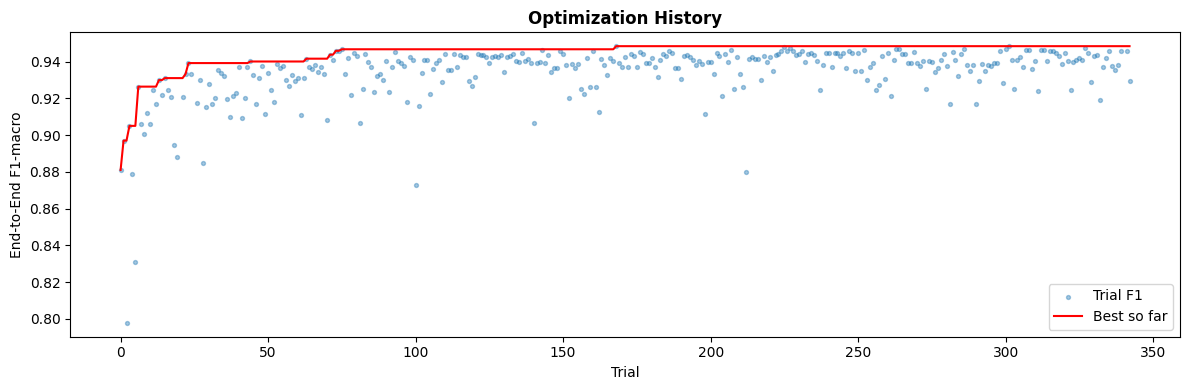

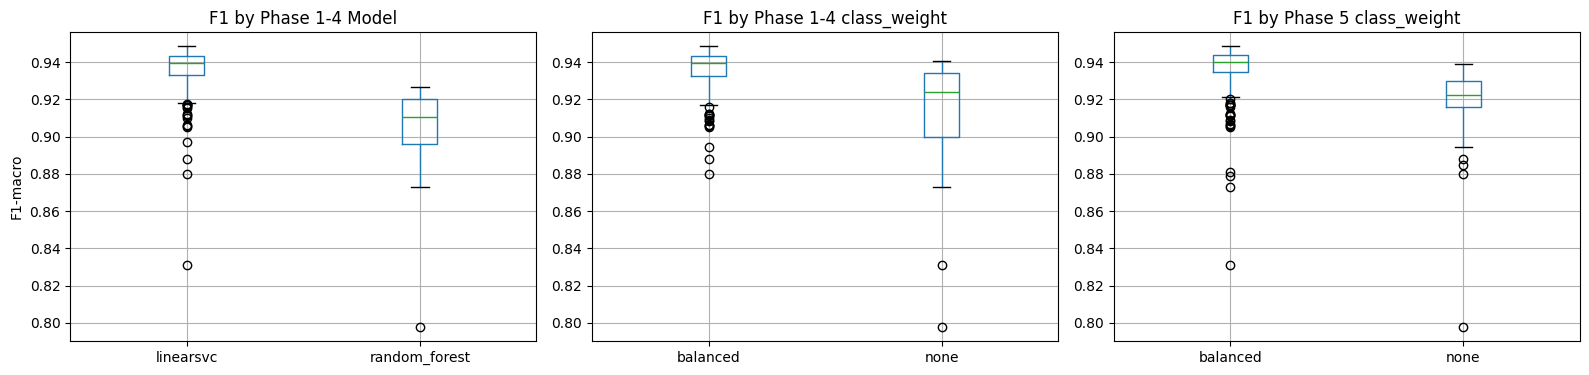

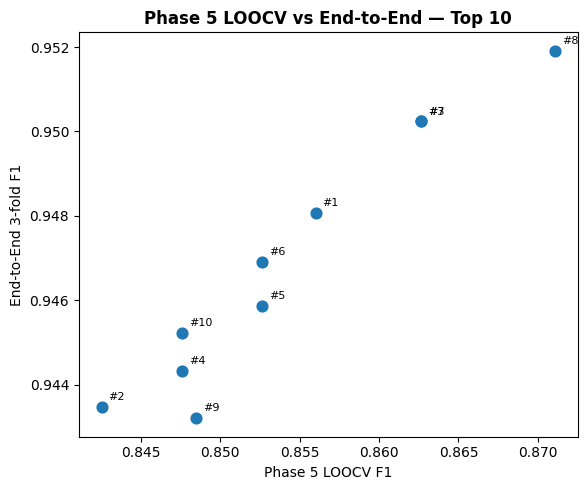

In [11]:
import matplotlib.pyplot as plt

if not all_results:
    if CHECKPOINT_FILE.exists():
        with open(CHECKPOINT_FILE, "r") as fp:
            all_results = json.load(fp)

if all_results:
    df_r = pd.DataFrame(all_results)

    # ── Optimization history ──────────────────────────────────
    trial_nums = [r["number"] for r in all_results]
    f1_vals = [r["f1_mean"] for r in all_results]
    order = np.argsort(trial_nums)
    t_sorted = np.array(trial_nums)[order]
    f1_sorted = np.array(f1_vals)[order]
    cummax = np.maximum.accumulate(f1_sorted)

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.scatter(t_sorted, f1_sorted, s=8, alpha=0.4, label="Trial F1")
    ax.plot(t_sorted, cummax, color="red", linewidth=1.5, label="Best so far")
    ax.set_xlabel("Trial")
    ax.set_ylabel("End-to-End F1-macro")
    ax.set_title("Optimization History", fontweight="bold")
    ax.legend()
    plt.tight_layout()
    plt.show()

    # ── Phase 1-4 model comparison ────────────────────────────
    df_r["p14_model"] = df_r["params"].apply(lambda p: p["p14_model"])
    df_r["p14_cw"] = df_r["params"].apply(lambda p: p["p14_class_weight"])
    df_r["hgb_cw"] = df_r["params"].apply(lambda p: p.get("hgb_class_weight", "N/A"))

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    df_r.boxplot(column="f1_mean", by="p14_model", ax=axes[0])
    axes[0].set_title("F1 by Phase 1-4 Model")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("F1-macro")

    df_r.boxplot(column="f1_mean", by="p14_cw", ax=axes[1])
    axes[1].set_title("F1 by Phase 1-4 class_weight")
    axes[1].set_xlabel("")

    df_r.boxplot(column="f1_mean", by="hgb_cw", ax=axes[2])
    axes[2].set_title("F1 by Phase 5 class_weight")
    axes[2].set_xlabel("")

    plt.suptitle("")
    plt.tight_layout()
    plt.show()

    # ── Validated: LOOCV vs E2E comparison ────────────────────
    if validated_results:
        fig, ax = plt.subplots(figsize=(6, 5))
        x_loo = [r["f1_p5_loocv"] for r in validated_results]
        y_e2e = [r["f1_e2e_3fold"] for r in validated_results]
        ax.scatter(x_loo, y_e2e, s=60, zorder=3)
        for i, r in enumerate(validated_results):
            ax.annotate(f"#{r['optuna_rank']}", (x_loo[i], y_e2e[i]),
                        textcoords="offset points", xytext=(5, 5), fontsize=8)
        ax.set_xlabel("Phase 5 LOOCV F1")
        ax.set_ylabel("End-to-End 3-fold F1")
        ax.set_title("Phase 5 LOOCV vs End-to-End — Top 10", fontweight="bold")
        plt.tight_layout()
        plt.show()

else:
    print("No results to plot. Run the tuning first.")

